# ✋✂️🧻 ResNet Transfer Learning with Rock-Paper-Scissors Dataset

This notebook demonstrates transfer learning using ResNet50V2 on the Rock-Paper-Scissors dataset from TensorFlow Datasets.

In [3]:
# 🛠 Fix the version mismatch
!pip install "protobuf==6.31.1" -q
print("✅ Protobuf 6.31.1 installed. Please restart your kernel now!")

✅ Protobuf 6.31.1 installed. Please restart your kernel now!


  You can safely remove it manually.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# 📦 Step 1: Configuration & Imports
import os
# Force the compatible implementation to prevent the 'FieldDescriptor' error
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# 🗂 Step 2: Load the Dataset
print("Loading Rock-Paper-Scissors dataset...")

(ds_train, ds_test), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,  # Returns (image, label) instead of a dictionary
    with_info=True,
)

# 📋 Step 3: Display Dataset Information
print("\n" + "="*30)
print("✅ DATASET LOADED SUCCESSFULLY")
print("="*30)
print(f"Dataset Name: {ds_info.name}")
print(f"Training Examples: {ds_info.splits['train'].num_examples}")
print(f"Testing Examples: {ds_info.splits['test'].num_examples}")
print(f"Image Shape: {ds_info.features['image'].shape}")
print(f"Class Names: {ds_info.features['label'].names}")
print("="*30)

Loading Rock-Paper-Scissors dataset...

✅ DATASET LOADED SUCCESSFULLY
Dataset Name: rock_paper_scissors
Training Examples: 2520
Testing Examples: 372
Image Shape: (300, 300, 3)
Class Names: ['rock', 'paper', 'scissors']


In [2]:
# 🧹 Step 3: Normalize and Batch the Data
def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

batch_size = 64

ds_train = ds_train.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache().shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

ds_test = ds_test.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [3]:
# 🧠 Step 4: Define the Transfer Learning Model
base_model = tf.keras.applications.ResNet50V2(
    input_shape=(300, 300, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Resizing(300, 300),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 10, 10, 2048)   │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,564,800 (89.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,564,800 (89.89 MB)

In [5]:
# 🚀 Step 5: Train the Model
history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=1
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 273s 7s/step - accuracy: 0.9603 - loss: 0.3712 - val_accuracy: 0.8172 - val_loss: 0.4247


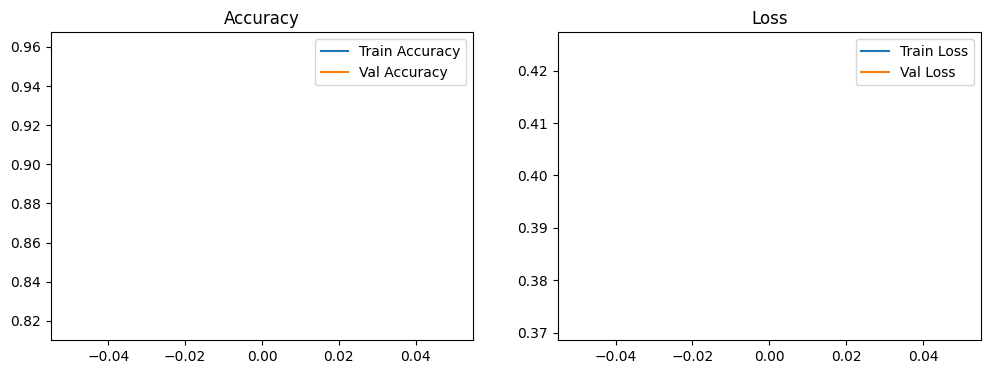

In [6]:
# 📈 Step 6: Visualize Training Results
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [7]:
# 🧪 Step 7: Evaluate on Test Set
test_loss, test_acc = model.evaluate(ds_test)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - accuracy: 0.8172 - loss: 0.4247
Test Accuracy: 0.8172, Test Loss: 0.4247


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


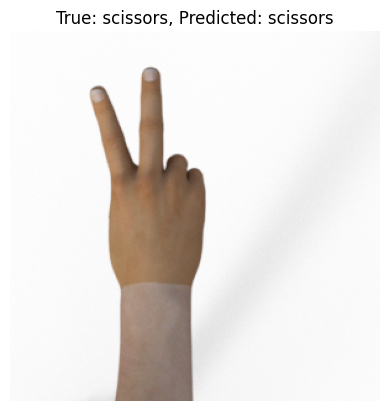

In [8]:
# 🔍 Step 8: Inference on a Random Test Image
import random
import tensorflow_datasets as tfds

# Load test data again without batching
raw_test_ds = tfds.load('rock_paper_scissors', split='test', as_supervised=True)

# Pick a random test sample
sample_list = list(raw_test_ds)
sample_image, sample_label = random.choice(sample_list)

# Preprocess image
input_image = tf.image.resize(sample_image, (300, 300)) / 255.0
input_image = tf.expand_dims(input_image, axis=0)  # Add batch dimension

# Predict
pred = model.predict(input_image)
predicted_class = tf.argmax(pred[0]).numpy()

# Class labels
class_names = ds_info.features['label'].names

# Display
plt.imshow(sample_image)
plt.title(f"True: {class_names[sample_label]}, Predicted: {class_names[predicted_class]}")
plt.axis('off')
plt.show()